<a href="https://colab.research.google.com/github/Rflavia/00_minera-o_dados/blob/main/01_analise_descritiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1 — Análise Descritiva: Candidatos 2026 (TSE)

Esta fase é **exploração pura**: olhar para os dados de candidatos e de bens declarados sem nenhum compromisso com o que vem depois (clusterização, regras de associação, anomalias). A ideia é conhecer o dataset por conta própria — distribuições, proporções, outliers, relações entre variáveis — **antes** de qualquer modelo apontar o que "importa". As fases seguintes vão te pedir pra escolher variáveis; essa escolha deve nascer do que você observar aqui, não o contrário.

Este notebook parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

Use os **mesmos valores** que você usou na Fase 0, para carregar o arquivo certo.

In [4]:
CARGO = "DEPUTADO FEDERALR"
UFS_REGIAO = ["PR", "RS" , "SC"]
ANO_ELEICAO = 2026

In [5]:
!git clone https://github.com/Rflavia/00_minera-o_dados.git

Cloning into '00_minera-o_dados'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 31 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 1.03 MiB | 4.22 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

arquivo = f"00_minera-o_dados/dados/candidatos_DEPUTADO_FEDERAL_SUL_2026.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: 00_minera-o_dados/dados/candidatos_DEPUTADO_FEDERAL_SUL_2026.csv  ->  1111 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,26/08/2026,12:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532588,4050,MARIO SETO TAKEGUMA JUNIOR,MARIO CERTO,#NULO,6434321910,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1987-01-07,92467190698,2,MASCULINO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),4,AMARELA,132,PSICÓLOGO,-1,#NULO,0.00,"45,000.00","11,544.24","87,605.86",0.00,"52,262.32","196,412.42",12.19,39
1,26/08/2026,12:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532589,4045,ANTÔNIO FERNANDO TEIGAO,FERNANDÃO,#NULO,30357934920,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1957-10-21,12790340663,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,257,EMPRESÁRIO,-1,#NULO,0.00,"87,000.00","4,984.47","25,453.75","15,000.00","227,871.27","360,309.49",12.79,69
2,26/08/2026,12:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532590,4000,CAMILLA DE MORAES GONDA,CAMILLA GONDA,#NULO,10555616924,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,2000-10-14,115434590639,4,FEMININO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),1,BRANCA,278,VEREADOR,-1,#NULO,0.00,0.00,0.00,"14,187.66",0.00,0.00,"14,187.66",9.56,25
3,26/08/2026,12:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532591,4070,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,CHARLESTON JÚNIOR INCLUSÃO,#NULO,10945908946,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,2004-07-05,124740900612,2,MASCULINO,7,SUPERIOR INCOMPLETO,1,SOLTEIRO(A),1,BRANCA,931,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,22
4,26/08/2026,12:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,PR,PR,PARANÁ,6,DEPUTADO FEDERAL,160002532592,4077,OMAR RAIMUNDO PICHETH NETO,OMAR PICHETH,#NULO,82002045968,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,40,PSB,PARTIDO SOCIALISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,160001800094,PARTIDO ISOLADO,PSB,PR,1971-07-28,46300400663,2,MASCULINO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,278,VEREADOR,-1,#NULO,"275,000.00","40,000.00",0.00,"19,686.98",0.00,0.00,"334,686.98",12.72,55


## 1) Visão geral: tamanho, tipos e dados ausentes

Antes de olhar variável por variável, um raio-x da tabela inteira.

1111 candidatos x 59 colunas



,nº de colunas
object,31
int64,20
float64,8


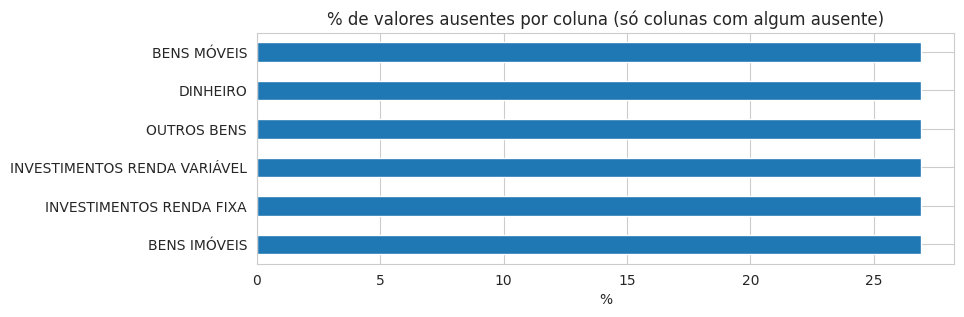

In [7]:
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas\n")
display(df.dtypes.value_counts().rename('nº de colunas'))

faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    plt.figure(figsize=(9, max(3, len(faltantes) * 0.3)))
    faltantes.plot(kind='barh')
    plt.title('% de valores ausentes por coluna (só colunas com algum ausente)')
    plt.xlabel('%')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

1) As colunas referentes às categorias de bens apresentam aproximadamente 27% de valores ausentes. Isso ocorre porque, na Fase 0, a tabela de candidatos foi combinada com a tabela de bens por meio de um left merge, mantendo todos os candidatos. Assim, candidatos sem correspondência na tabela de bens ficaram com NaN nessas categorias. Portanto, esses valores ausentes não devem ser interpretados diretamente como ausência de patrimônio.

## 2) Escolhendo o que explorar

O dataset tem dezenas de colunas — muitas são identificadores administrativos (`SQ_CANDIDATO`, `NR_CPF_CANDIDATO`, `DS_EMAIL`, hashes de geração...) sem valor analítico. As duas listas abaixo reúnem as colunas com conteúdo substantivo — **sintam-se livres para adicionar outras que despertarem curiosidade** (`df.columns` mostra tudo o que está disponível).

In [8]:
display(pd.DataFrame({"Coluna": df.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,ANO_ELEICAO
3,CD_TIPO_ELEICAO
4,NM_TIPO_ELEICAO
5,NR_TURNO
6,CD_ELEICAO
7,DS_ELEICAO
8,DT_ELEICAO
9,TP_ABRANGENCIA


In [16]:
colunas_numericas = [
    'IDADE',
    'Total_Bens',
    'Total_Bens_Log',
    'BENS MÓVEIS',
    'BENS IMÓVEIS',
    'DINHEIRO',
    'INVESTIMENTOS RENDA FIXA',
    'INVESTIMENTOS RENDA VARIÁVEL',
    'OUTROS BENS',
]
colunas_numericas = [c for c in colunas_numericas if c in df.columns]

colunas_categoricas = [
    'DS_GENERO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'DS_GRAU_INSTRUCAO',
    'DS_SITUACAO_CANDIDATURA',
    'DS_SIT_TOT_TURNO',
    'TP_AGREMIACAO',
    'SG_PARTIDO',
    'DS_OCUPACAO',
    'NR_TURNO',
    'SG_UE',
]
colunas_categoricas = [c for c in colunas_categoricas if c in df.columns]

print("Numéricas:")
display(pd.DataFrame({"Coluna": colunas_numericas}))
print("Categóricas:")
display(pd.DataFrame({"Coluna": colunas_categoricas}))

Numéricas:


,Coluna
0,IDADE
1,Total_Bens
2,Total_Bens_Log
3,BENS MÓVEIS
4,BENS IMÓVEIS
5,DINHEIRO
6,INVESTIMENTOS RENDA FIXA
7,INVESTIMENTOS RENDA VARIÁVEL
8,OUTROS BENS


Categóricas:


,Coluna
0,DS_GENERO
1,DS_ESTADO_CIVIL
2,DS_COR_RACA
3,DS_GRAU_INSTRUCAO
4,DS_SITUACAO_CANDIDATURA
5,DS_SIT_TOT_TURNO
6,TP_AGREMIACAO
7,SG_PARTIDO
8,DS_OCUPACAO
9,NR_TURNO


## 3) Variáveis numéricas: distribuição e outliers

In [14]:
display(df[colunas_numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
IDADE,"1,111.00",48.58,12.42,21.00,40.00,48.00,58.00,85.00
Total_Bens,"1,111.00","1,006,523.38","4,502,465.51",0.00,0.00,"157,849.37","710,000.00","75,659,161.21"
Total_Bens_Log,"1,111.00",9.21,5.85,0.00,0.00,11.97,13.47,18.14
BENS MÓVEIS,812.00,"84,361.71","183,311.56",0.00,0.00,"38,553.50","113,218.00","3,850,661.80"
BENS IMÓVEIS,812.00,"552,778.74","1,457,467.80",0.00,0.00,"155,330.83","600,000.00","28,900,209.44"
DINHEIRO,812.00,"35,420.77","161,587.90",0.00,0.00,0.00,"5,452.61","2,600,897.69"
INVESTIMENTOS RENDA FIXA,812.00,"67,350.26","785,924.92",0.00,0.00,0.00,385.59,"21,918,279.03"
INVESTIMENTOS RENDA VARIÁVEL,812.00,"107,057.34","634,970.73",0.00,0.00,0.00,0.00,"10,758,693.96"
OUTROS BENS,812.00,"530,183.25","3,956,367.01",0.00,0.00,0.00,"78,680.14","64,787,400.00"


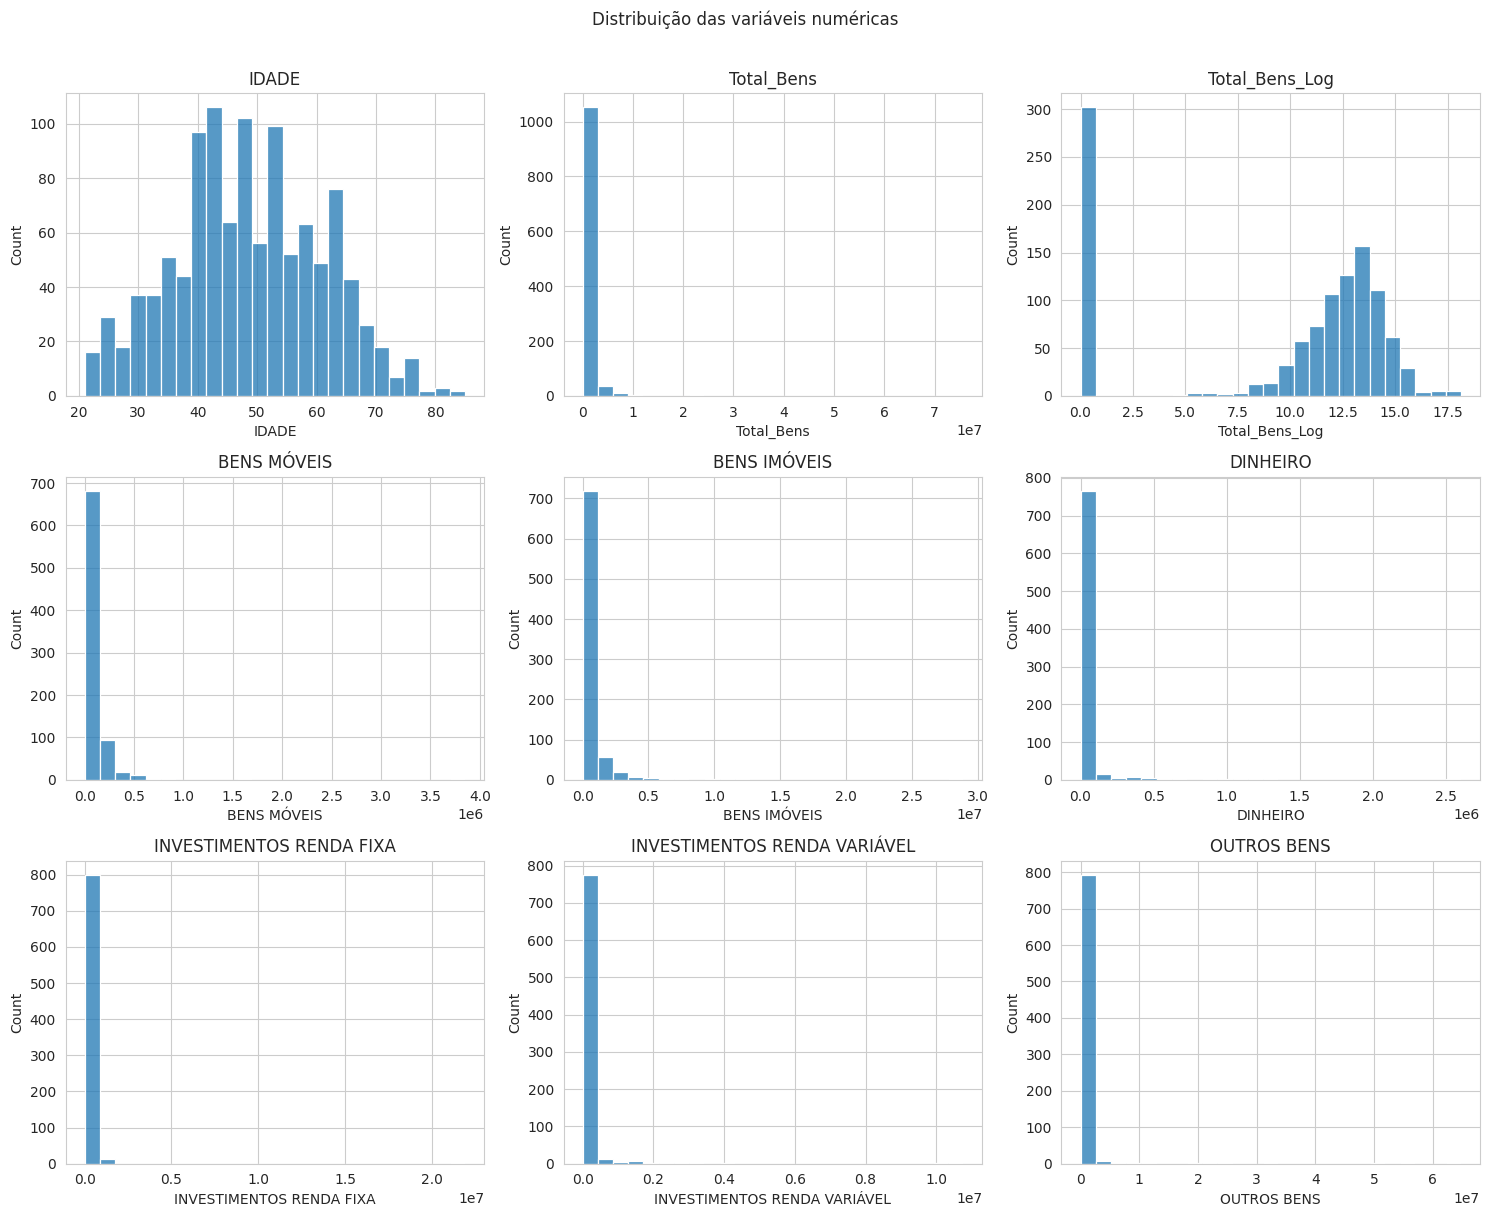

In [15]:
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], bins=25, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.01)
plt.tight_layout()
plt.show()

Observa-se que muitos dos candidatos estão nas faixas patrimoniais mais baixas quando comparados aos maiores patrimônios da base.

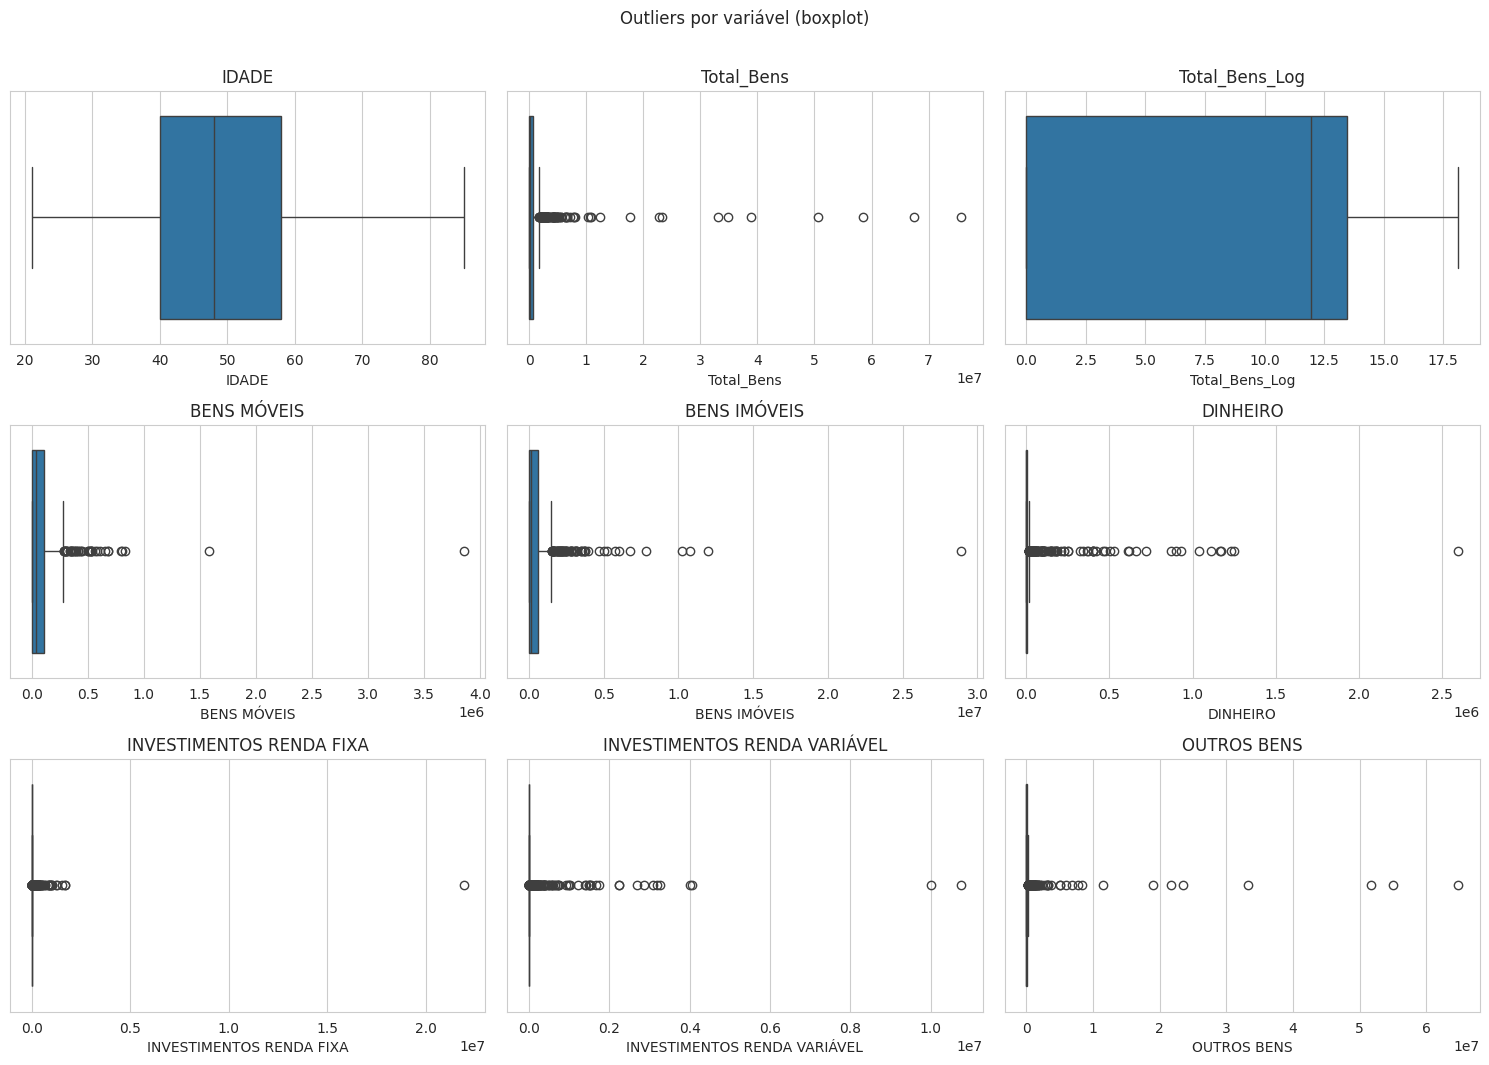

In [17]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variável (boxplot)', y=1.01)
plt.tight_layout()
plt.show()

### 3.1) Quantificando os outliers (regra do IQR)

O boxplot mostra visualmente; esta tabela quantifica: quantos candidatos ficam fora do intervalo `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` em cada variável.

In [18]:
linhas = []
for col in colunas_numericas:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    linhas.append({
        'variavel': col, 'limite_inferior': lim_inf, 'limite_superior': lim_sup,
        'qtd_outliers': n_outliers, 'pct_outliers': round(100 * n_outliers / len(df), 1),
    })

pd.DataFrame(linhas).sort_values('pct_outliers', ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,pct_outliers
7,INVESTIMENTOS RENDA VARIÁVEL,0.00,0.00,194,17.50
6,INVESTIMENTOS RENDA FIXA,-578.38,963.97,194,17.50
5,DINHEIRO,"-8,178.91","13,631.52",156,14.00
8,OUTROS BENS,"-118,020.21","196,700.34",131,11.80
1,Total_Bens,"-1,065,000.00","1,775,000.00",117,10.50
4,BENS IMÓVEIS,"-900,000.00","1,500,000.00",71,6.40
3,BENS MÓVEIS,"-169,827.00","283,045.00",44,4.00
0,IDADE,13.00,85.00,0,0.00
2,Total_Bens_Log,-20.21,33.68,0,0.00


## 4) Variáveis categóricas: contagens e proporções

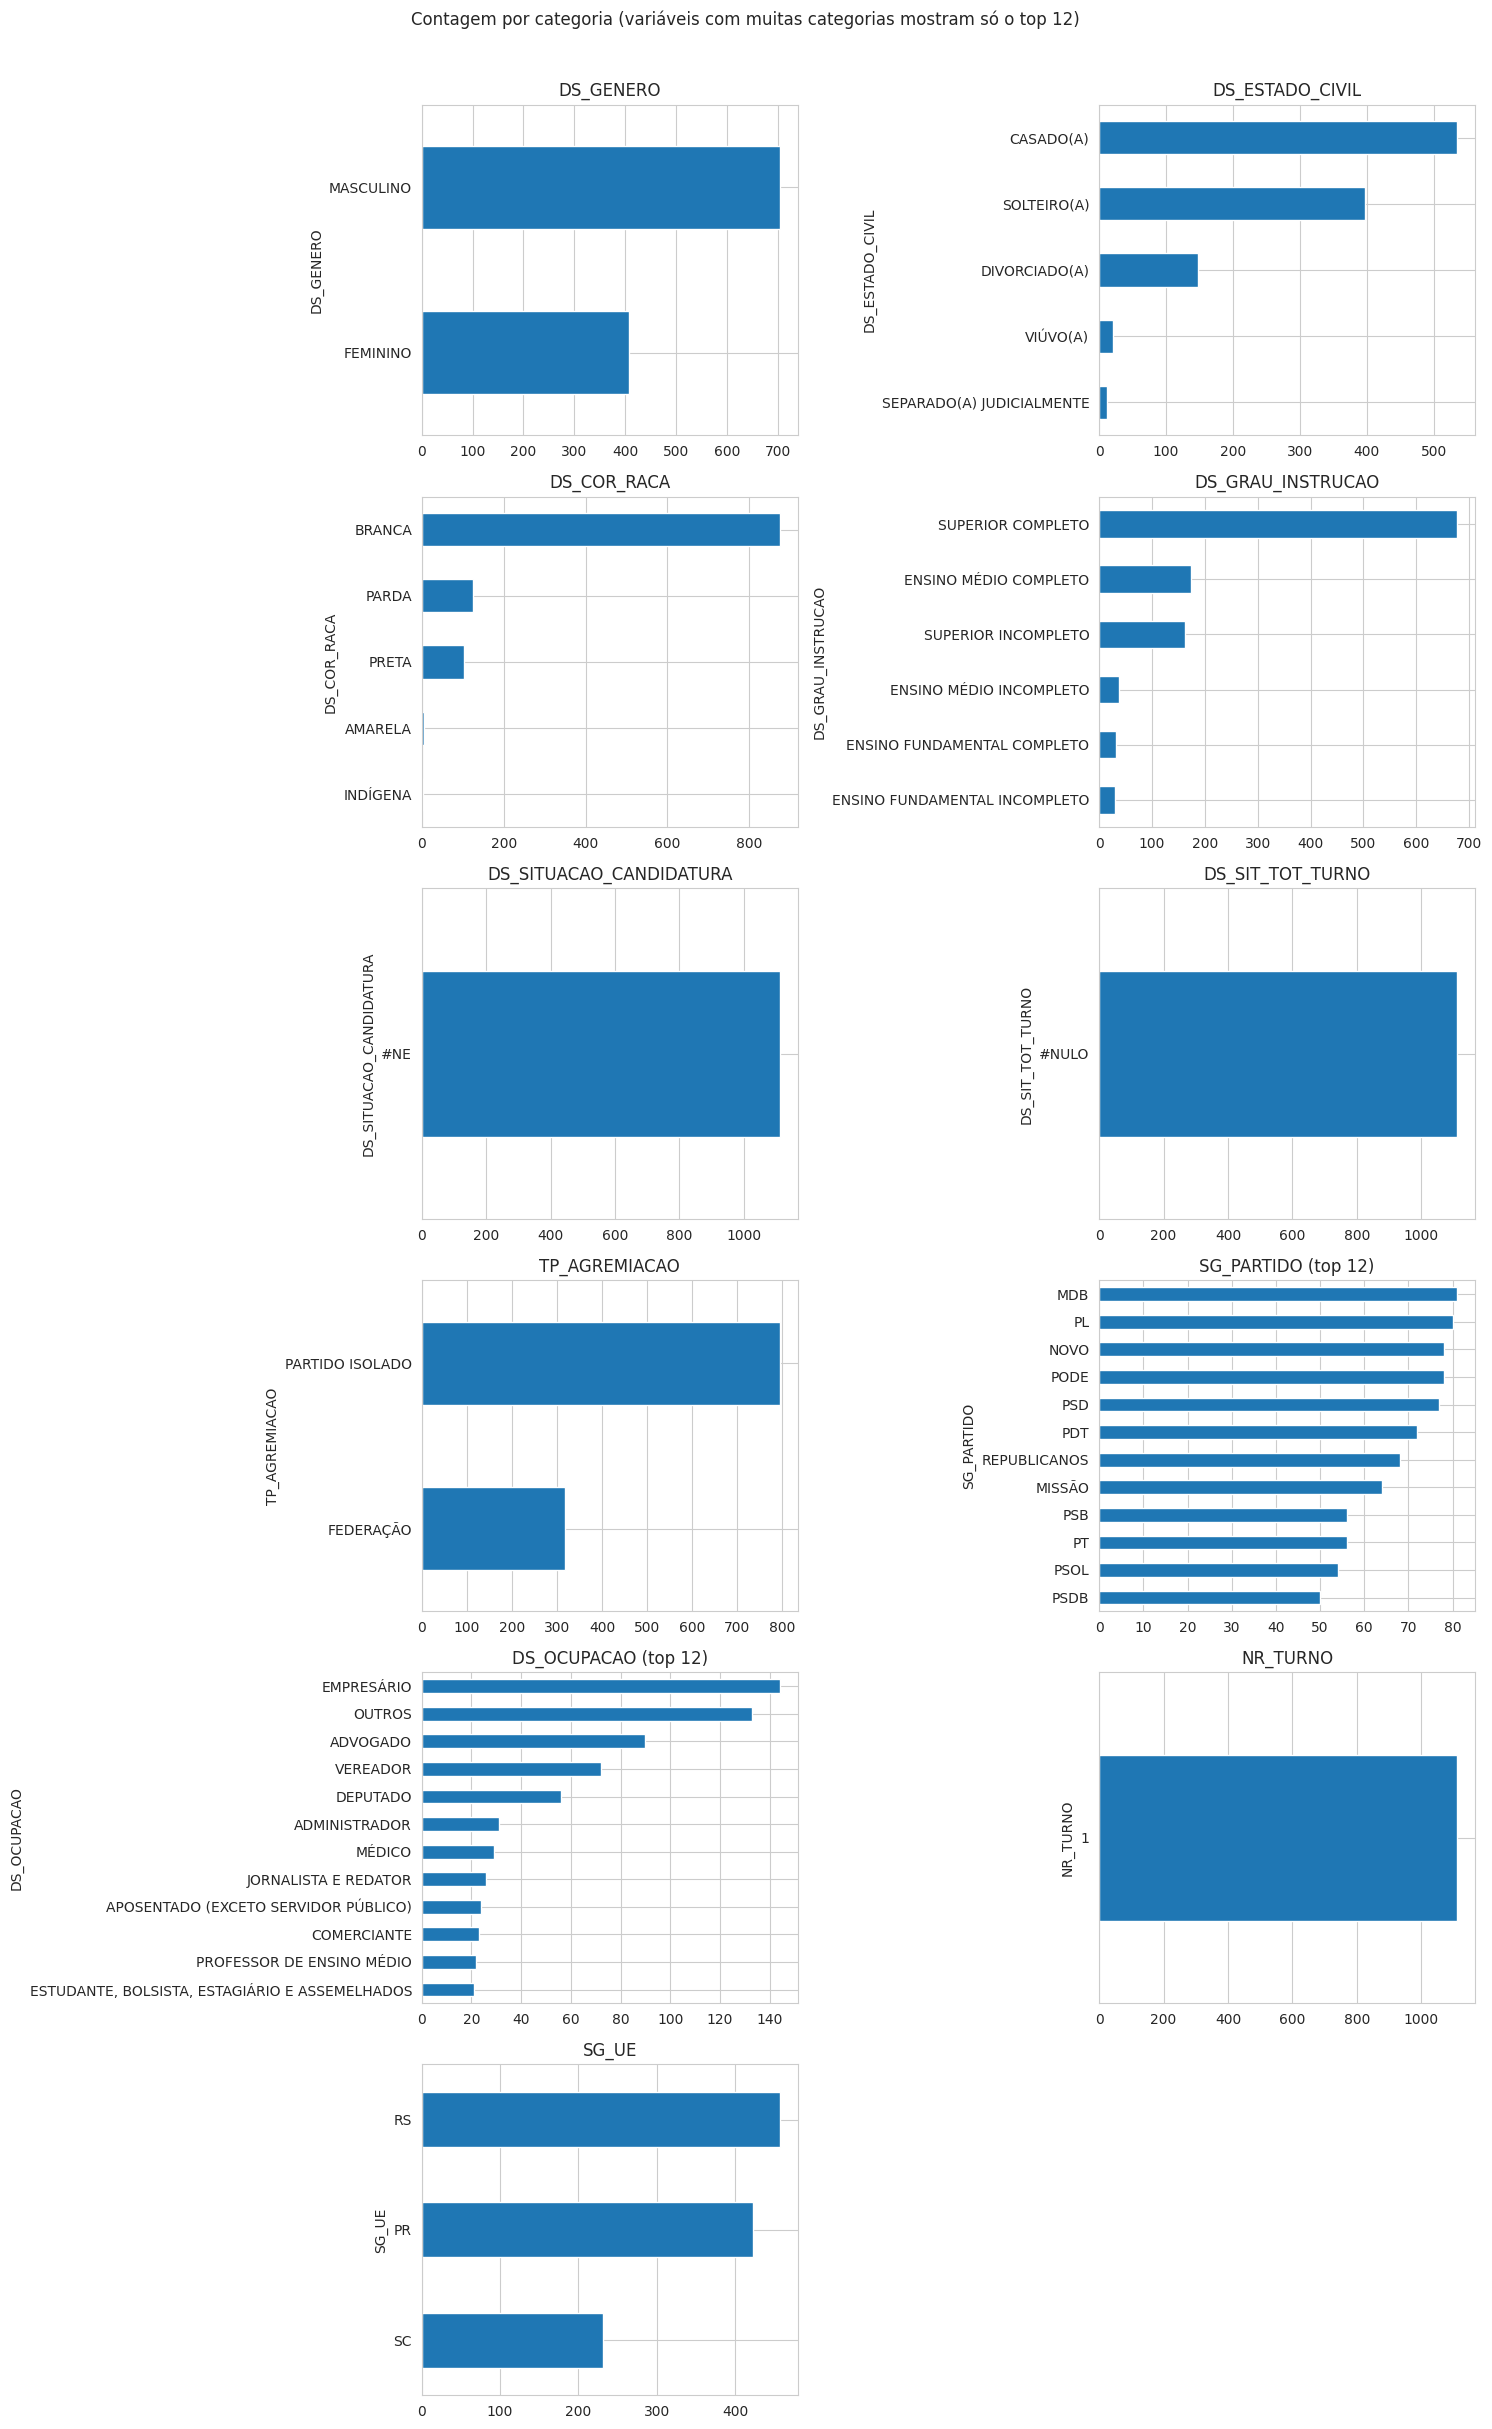

In [19]:
def plot_categorica(ax, coluna, top_n=12):
    contagem = df[coluna].value_counts().head(top_n)
    contagem.plot(kind='barh', ax=ax)
    ax.set_title(coluna + (f' (top {top_n})' if df[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Contagem por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
for col in colunas_categoricas:
    print(f"--- {col} ({df[col].nunique()} categorias) ---")
    print((df[col].value_counts(normalize=True).head(8) * 100).round(1).astype(str) + '%')
    print()

--- DS_GENERO (2 categorias) ---
DS_GENERO
MASCULINO    63.4%
FEMININO     36.6%
Name: proportion, dtype: object

--- DS_ESTADO_CIVIL (5 categorias) ---
DS_ESTADO_CIVIL
CASADO(A)                    48.2%
SOLTEIRO(A)                  35.7%
DIVORCIADO(A)                13.3%
VIÚVO(A)                      1.8%
SEPARADO(A) JUDICIALMENTE     1.0%
Name: proportion, dtype: object

--- DS_COR_RACA (5 categorias) ---
DS_COR_RACA
BRANCA      78.7%
PARDA       11.2%
PRETA        9.3%
AMARELA      0.5%
INDÍGENA     0.4%
Name: proportion, dtype: object

--- DS_GRAU_INSTRUCAO (6 categorias) ---
DS_GRAU_INSTRUCAO
SUPERIOR COMPLETO                60.9%
ENSINO MÉDIO COMPLETO            15.6%
SUPERIOR INCOMPLETO              14.7%
ENSINO MÉDIO INCOMPLETO           3.3%
ENSINO FUNDAMENTAL COMPLETO       2.9%
ENSINO FUNDAMENTAL INCOMPLETO     2.6%
Name: proportion, dtype: object

--- DS_SITUACAO_CANDIDATURA (1 categorias) ---
DS_SITUACAO_CANDIDATURA
#NE    100.0%
Name: proportion, dtype: object

--- DS_SI

A população analisada é majoritariamente masculina (63,4%), branca (78,7%) e com ensino superior completo (60,9%). Em relação à distribuição geográfica, o RS concentra 41,1% dos candidatos, seguido por PR com 38,1% e SC com 20,8%.

## 5) Dispersão entre variáveis numéricas

Correlação e gráficos de dispersão par a par — sem nenhuma variável de destaque, só pra ver como as variáveis se relacionam (ou não).

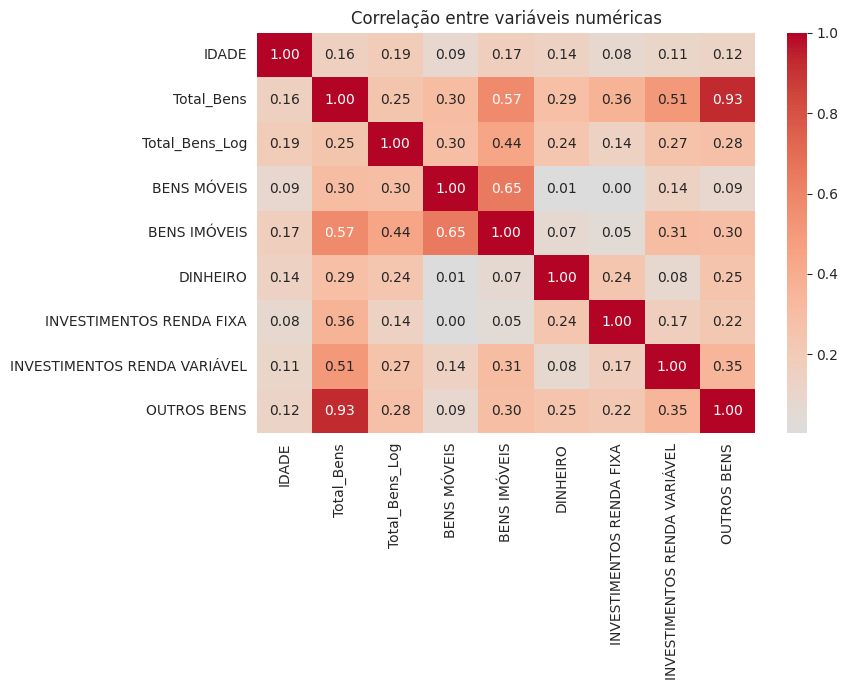

In [22]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

A idade, por exemplo, apresenta baixa correlação positiva com o patrimônio total (0,16), indicando que candidatos mais velhos tendem a apresentar patrimônio ligeiramente maior, porém a relação é fraca

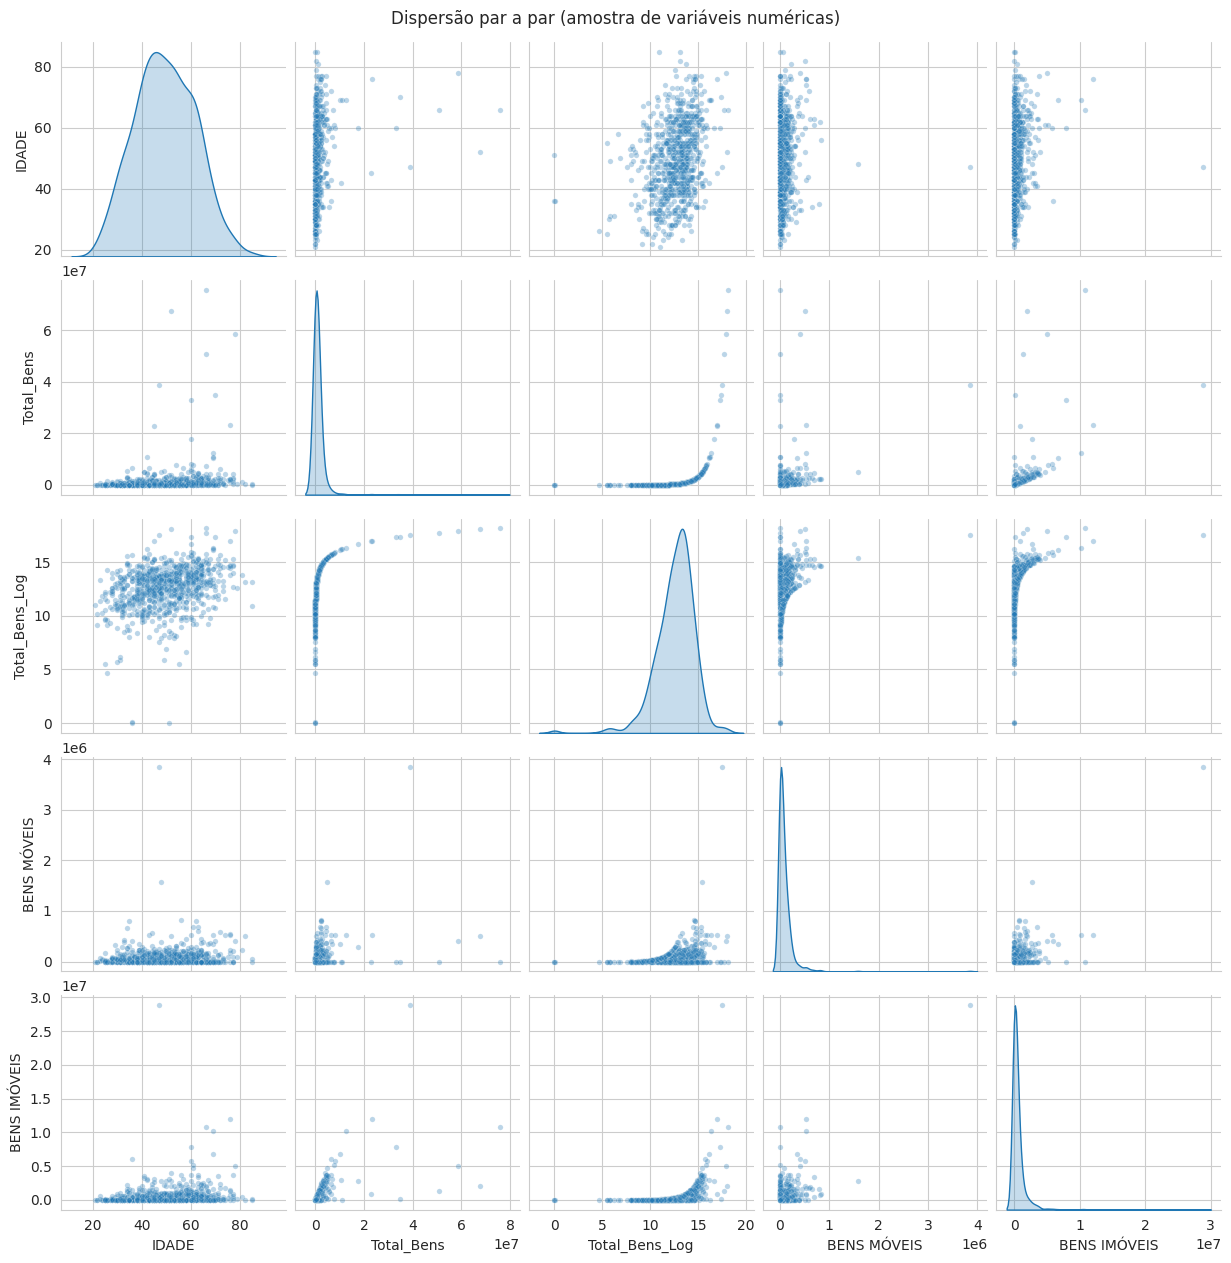

In [23]:
# Pairplot com um subconjunto (pairplot com muitas variáveis fica pesado/ilegível)
subset = colunas_numericas[:5]
sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Dispersão par a par (amostra de variáveis numéricas)', y=1.01)
plt.show()

### 5.1) Um exemplo de dispersão colorida

Só um exemplo de como cruzar uma variável numérica com outra numérica *e* uma categórica ao mesmo tempo — troquem `x`, `y` e `hue` livremente para explorar outras combinações.

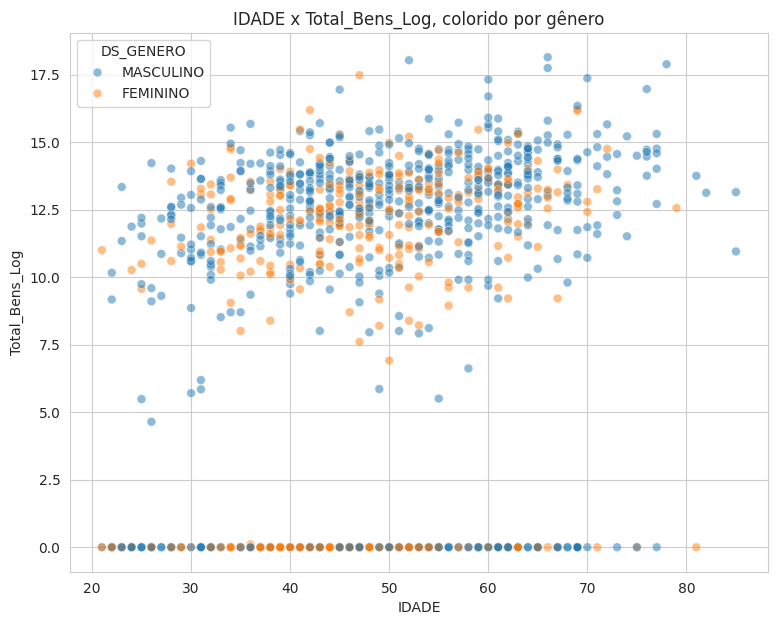

In [24]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='IDADE', y='Total_Bens_Log', hue='DS_GENERO', alpha=0.5, s=40)
plt.title('IDADE x Total_Bens_Log, colorido por gênero')
plt.show()

## 6) Proporções entre grupos

Alguns exemplos de cruzamentos categóricos — não são os únicos possíveis, só uma amostra do tipo de pergunta que dá pra fazer.

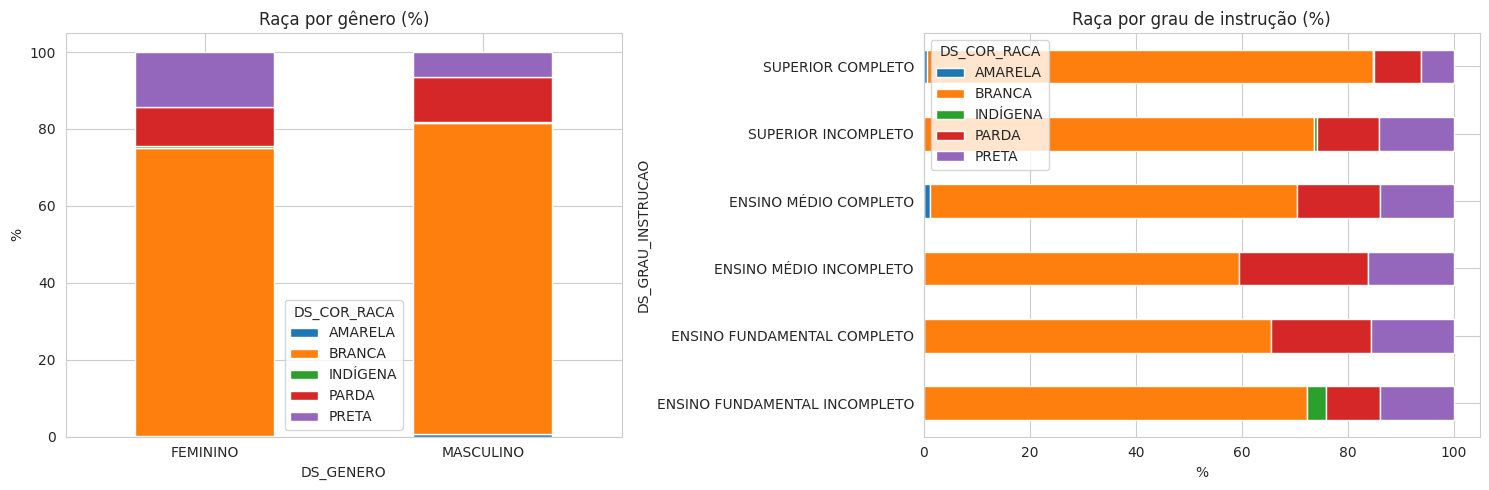

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df['DS_GENERO'], df['DS_COR_RACA'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0]
)
axes[0].set_title('Raça por gênero (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

ordem_instrucao = df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']].drop_duplicates().sort_values('CD_GRAU_INSTRUCAO')['DS_GRAU_INSTRUCAO']
pd.crosstab(df['DS_GRAU_INSTRUCAO'], df['DS_COR_RACA'], normalize='index').loc[ordem_instrucao].mul(100).plot(
    kind='barh', stacked=True, ax=axes[1]
)
axes[1].set_title('Raça por grau de instrução (%)')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

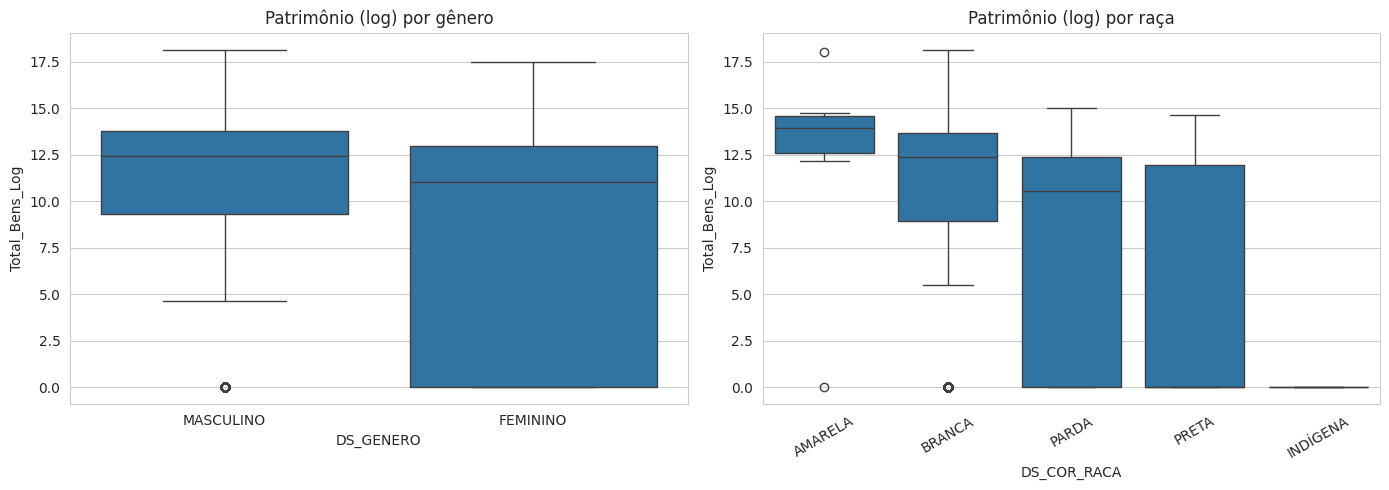

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GENERO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_COR_RACA', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

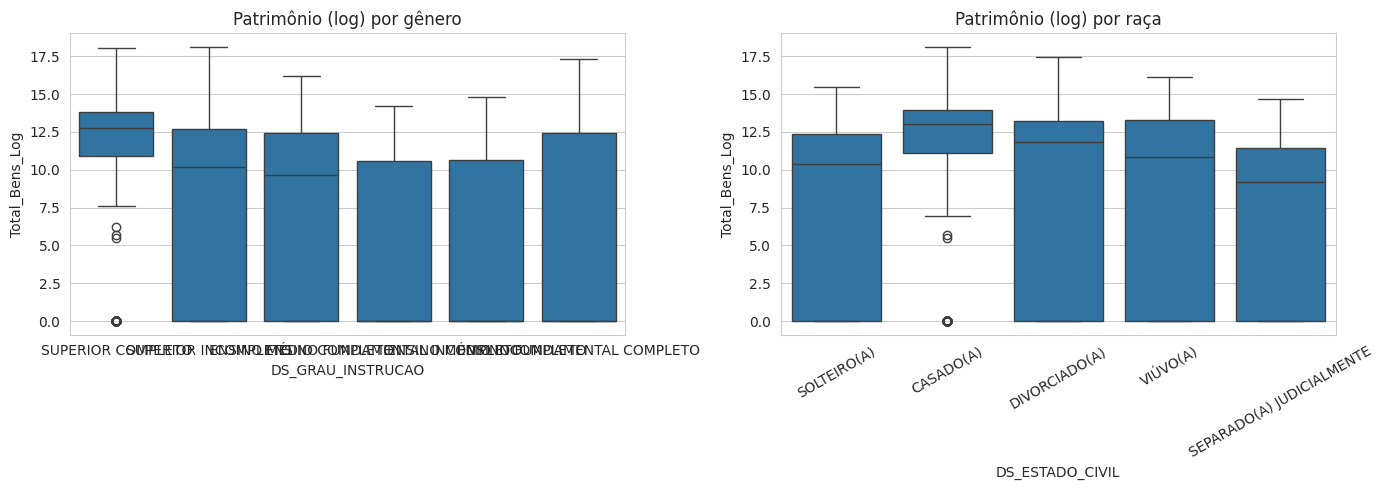

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='DS_GRAU_INSTRUCAO', y='Total_Bens_Log', ax=axes[0])
axes[0].set_title('Patrimônio (log) por gênero')

sns.boxplot(data=df, x='DS_ESTADO_CIVIL', y='Total_Bens_Log', ax=axes[1])
axes[1].set_title('Patrimônio (log) por raça')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

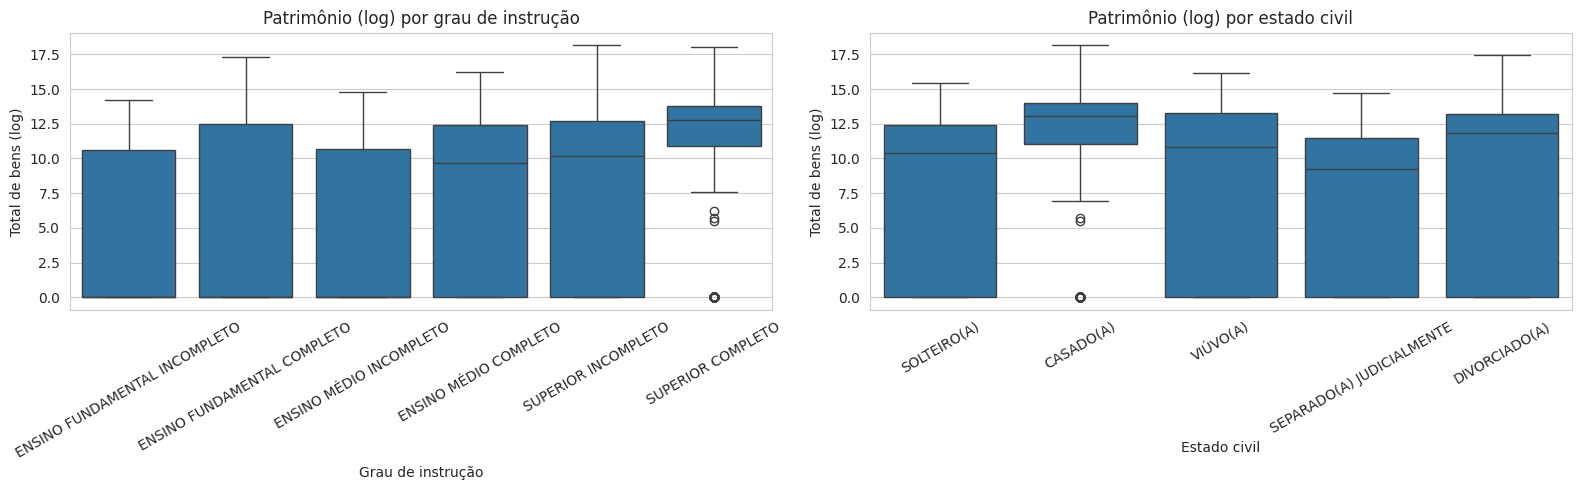

In [29]:
# Ordem do grau de instrução pelo respectivo código
ordem_instrucao = (
    df[['CD_GRAU_INSTRUCAO', 'DS_GRAU_INSTRUCAO']]
    .drop_duplicates()
    .sort_values('CD_GRAU_INSTRUCAO')
    ['DS_GRAU_INSTRUCAO']
    .tolist()
)

# Ordem do estado civil pelo respectivo código
ordem_estado_civil = (
    df[['CD_ESTADO_CIVIL', 'DS_ESTADO_CIVIL']]
    .drop_duplicates()
    .sort_values('CD_ESTADO_CIVIL')
    ['DS_ESTADO_CIVIL']
    .tolist()
)


# Cria os dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Grau de instrução
sns.boxplot(
    data=df,
    x='DS_GRAU_INSTRUCAO',
    y='Total_Bens_Log',
    order=ordem_instrucao,
    ax=axes[0]
)

axes[0].set_title('Patrimônio (log) por grau de instrução')
axes[0].set_xlabel('Grau de instrução')
axes[0].set_ylabel('Total de bens (log)')
axes[0].tick_params(axis='x', rotation=30)


# Estado civil
sns.boxplot(
    data=df,
    x='DS_ESTADO_CIVIL',
    y='Total_Bens_Log',
    order=ordem_estado_civil,
    ax=axes[1]
)

axes[1].set_title('Patrimônio (log) por estado civil')
axes[1].set_xlabel('Estado civil')
axes[1].set_ylabel('Total de bens (log)')
axes[1].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.show()

## 7) Comparação entre UFs

Esta seção só roda na visão **Brasil** (quando `UF = None`) — não se aplica ao recorte por estado.

,qtd_candidatos,idade_media,patrimonio_mediano,pct_feminino
SG_UF,,,,
RS,457,49.60,"95,165.00",35.20
PR,423,48.40,"243,077.30",34.80
SC,231,46.90,"189,885.50",42.90


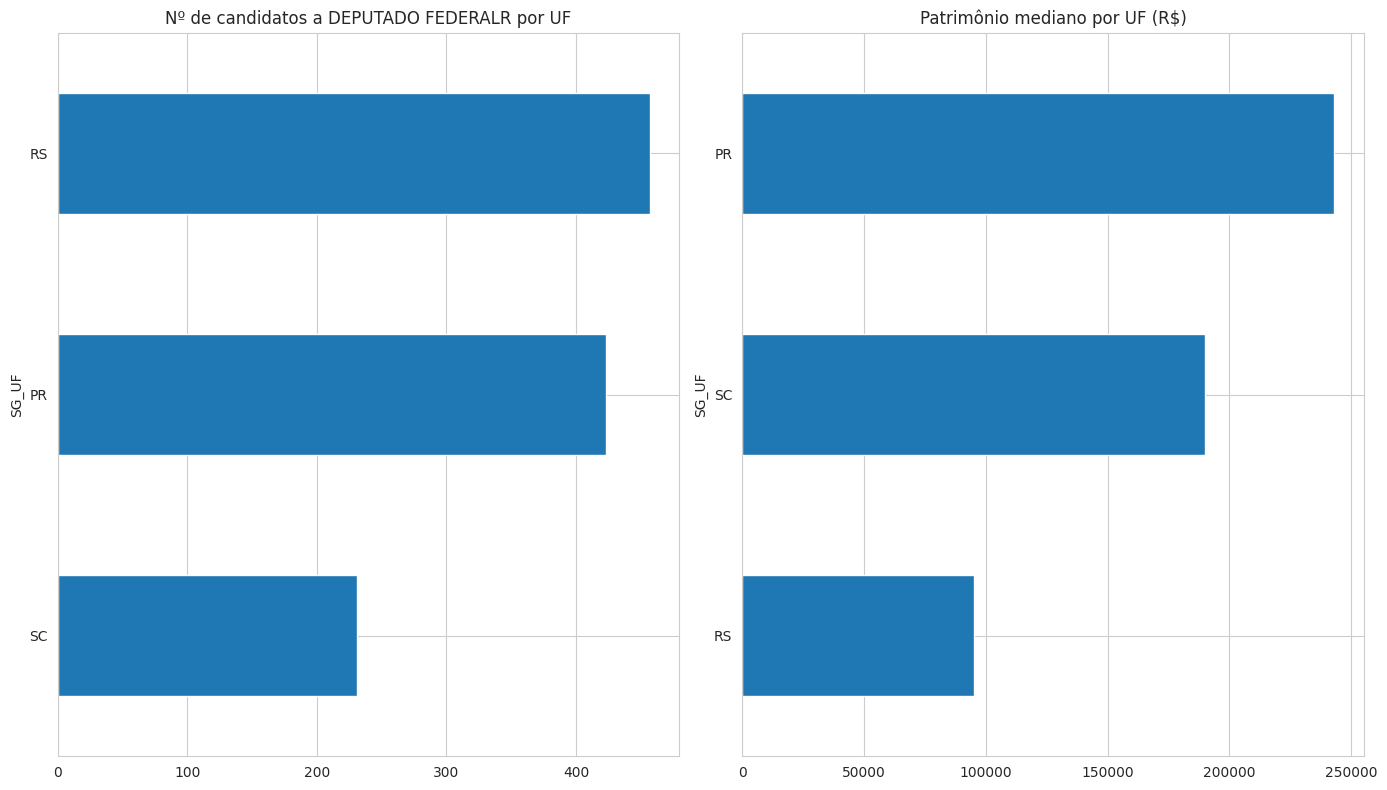

In [36]:
resumo_uf = df.groupby('SG_UF').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
    pct_feminino=('DS_GENERO', lambda x: (x == 'FEMININO').mean() * 100)
).round(1).sort_values('qtd_candidatos', ascending=False)

display(resumo_uf)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

resumo_uf['qtd_candidatos'].sort_values().plot(
    kind='barh',
    ax=axes[0]
)
axes[0].set_title(f'Nº de candidatos a {CARGO} por UF')

resumo_uf['patrimonio_mediano'].sort_values().plot(
    kind='barh',
    ax=axes[1]
)
axes[1].set_title('Patrimônio mediano por UF (R$)')

plt.tight_layout()
plt.show()

---
## Fechamento

Este notebook não teve o objetivo de "preparar terreno" para nenhuma técnica específica — foi só olhar para os dados. Antes de seguir, escrevam algumas observações próprias: quais variáveis têm mais outliers? Alguma proporção chamou atenção? Alguma dispersão sugere relação entre variáveis (ou ausência dela)? Essas observações são o ponto de partida — não a conclusão — das próximas fases.

## Próximo passo

**Fase 2 — Clusterização** (K-Means, DBSCAN, hierárquico e Bisecting K-Means) — liberada em breve. A escolha de variáveis para essa fase parte do que vocês observaram aqui.